In [1]:
!pip install pandas nltk scipy matplotlib openpyxl
!pip install openpyxl
!pip install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
full_dataset_path = "../resources/gemma3_4b/sampled_reviews_with_output_multicall_gemma3_4b.csv"
half_dataset_path = "../resources/gemma3_4b/comparison/gemma3_4b/500_sampled_reviews_with_output_multicall_gemma3_4b.csv"

In [3]:
import pandas as pd
import re
import json

In [4]:
full_dataset_df = pd.read_csv(full_dataset_path)
half_dataset_df = pd.read_csv(half_dataset_path)

In [5]:
full_dataset_df.head(5)

,review,sentiment,entities,json,progressive_index,output,json_output
0,"1st watched 2/9/2008, 4 out of 10(Dir-J.S. Car...",negative,"[{'label': 'ORG', 'value': 'qwest'}, {'label':...","{""review"": ""1st watched 2/9/2008, 4 out of 10(...",435,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""1st ..."
1,Following on directly from the last episode of...,positive,"[{'label': 'PERSON', 'value': 'Hacker'}, {'lab...","{""review"": ""Following on directly from the las...",3279,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""Foll..."
2,But at least this movie got what it deserved -...,negative,"[{'label': 'PERSON', 'value': 'Mike'}, {'label...","{""review"": ""But at least this movie got what i...",968,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""But ..."
3,A few buddies and myself have the strange hobb...,negative,"[{'label': 'PERSON', 'value': 'Larry Buchanan'...","{""review"": ""A few buddies and myself have the ...",1983,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""A fe..."
4,On a routine mission in Iraq a group of Delta ...,positive,"[{'label': 'ORG', 'value': 'Delta'}, {'label':...","{""review"": ""On a routine mission in Iraq a gro...",2903,"```json\n{\n ""sentiment"": ""positive"",\n ""revie...","{\n ""sentiment"": ""positive"",\n ""review"": ""On a..."


In [6]:
half_dataset_df.head(5)

,review,sentiment,entities,json,progressive_index,output,json_output
0,"To be honest fellow IMDb reviewers, I enjoyed ...",positive,"[{'label': 'ORG', 'value': 'IMDb'}, {'label': ...","{""review"": ""To be honest fellow IMDb reviewers...",4875,"```json\n{\n ""sentiment"": ""positive"",\n ""rev...","{\n ""sentiment"": ""positive"",\n ""review"": ""To..."
1,Being from the Buffalo area I was well aware o...,positive,[],"{""review"": ""Being from the Buffalo area I was ...",2789,"```json\n{\n ""sentiment"": ""positive"",\n ""revie...","{\n ""sentiment"": ""positive"",\n ""review"": ""Bein..."
2,"I watch family affairs,coronation st &east end...",negative,"[{'label': 'ORG', 'value': 'uktv'}, {'label': ...","{""review"": ""I watch family affairs,coronation ...",3147,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""I wa..."
3,36/100. This is not to be confused with the de...,negative,[],"{""review"": ""36/100. This is not to be confused...",3908,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""36/1..."
4,The hip hop rendition of a mos def performance...,positive,"[{'label': 'PERSON', 'value': 'mos def'}, {'la...","{""review"": ""The hip hop rendition of a mos def...",2844,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""The ..."


In [7]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [8]:
smoothing_function = SmoothingFunction()

ZERO_SCORE = ({
                "review_score": .0,
                "sentiment_score": .0,
                "ner_score": {
                    "accuracy": .0,
                    "precision": .0,
                    "recall": .0,
                    "f1": .0
                }
            }, .0)

In [9]:
def compute_bleu(reference: str, hypothesis: str) -> float:
    """
    Calcola lo score BLEU tra ipotesi e riferimento.

    Argomenti:
        reference (str): Il testo di riferimento.
        hypothesis (str): L'ipotesi da valutare.

    Return:
        Lo score BLEU.
    """
    return corpus_bleu([[reference.split()]], [hypothesis.split() if isinstance(hypothesis, str) else hypothesis],
                     smoothing_function=smoothing_function.method1)


In [10]:
def parse(string: str) -> dict:
    """
    Tenta di convertire una stringa in un dizionario.
    
    Argomenti:
        string (str): La stringa da convertire.
        
    Return:
        Il dizionario parsato o None in caso di errore.
    """
    dictionary = None
    try:
        dictionary = json.loads(string)
    except Exception:
        pass
    try:
        dictionary = eval(string)
    except Exception:
        pass
    return dictionary

In [11]:
def evaluate(row: pd.DataFrame) -> (dict, float):
    """
    Valuta una riga del dataframe confrontando l'output generato con la ground truth.
    
    Argomenti:
        row (pd.DataFrame): La riga da valutare.
        
    Return:
        Una tupla contenente i dettagli dello score e lo score medio.
    """
    ground_truth = parse(row["json"])
    if ground_truth is None:
        return ZERO_SCORE, 0.0

    if "json_output" not in row:
        return ZERO_SCORE, 0.0

    output = row["json_output"]
    
    output_dict = parse(output)
    if output_dict is None:
        return ZERO_SCORE, 0.0

    gt_review = ground_truth["review"] if "review" in ground_truth and isinstance(ground_truth["review"], str) else None
    out_review = output_dict["review"] if "review" in output_dict and isinstance(output_dict["review"], str) else None

    review_score = compute_bleu(gt_review,
                                     out_review) if gt_review is not None and out_review is not None else .0
    sentiment_score = 1.0 if "sentiment" in output_dict and output_dict["sentiment"] == ground_truth[
        "sentiment"] else 0.0

    ground_truth_entities = ground_truth["entities"]
    score = {
        "review_score": review_score,
        "sentiment_score": sentiment_score,
        "ner_score": {
            "accuracy": .0,
            "precision": .0,
            "recall": .0,
            "f1": .0
        }
    }
    if "entities" not in output_dict:
        return score, sum([review_score, sentiment_score, .0]) / 3.0

    detected_entities = output_dict["entities"] if "entities" in output_dict else []
    if len(detected_entities) == 0 and len(ground_truth_entities) == 0:
        score["ner_score"]["accuracy"] = 1.0
        score["ner_score"]["precision"] = 1.0
        score["ner_score"]["recall"] = 1.0
        score["ner_score"]["f1"] = 1.0
        return score, sum([review_score, sentiment_score, 1.0]) / 3.0

    false_negatives = 0  # Quelli che ci sono in GT, ma non nei detected
    false_positives = 0  # Quelli che sono stati individuati, ma non ci sono in GT
    true_positives = 0  # Quelli che sono stati correttamente individuati

    for ge in ground_truth_entities:
        ge_found = False
        for de in detected_entities:
            if "label" not in de or "value" not in de or len(de.items()) != 2:
                continue
            label = de["label"]
            value = de["value"]
            if label == ge["label"] and value == ge["value"]:
                ge_found = True
                break
        if ge_found:
            true_positives += 1
        else:
            false_negatives += 1

    for de in detected_entities:
        if "label" not in de or "value" not in de or len(de.items()) != 2:
            false_positives += 1
            continue
        label = de["label"]
        value = de["value"]
        ge_found = False
        for ge in ground_truth_entities:
            if label == ge["label"] and value == ge["value"]:
                ge_found = True
                break
        if not ge_found:
            false_positives += 1

    score["ner_score"]["accuracy"] = true_positives / (
            true_positives + false_positives + false_negatives) if true_positives + false_positives + false_negatives > 0 else .0
    score["ner_score"]["precision"] = true_positives / (
            true_positives + false_positives) if true_positives + false_positives > 0 else .0
    score["ner_score"]["recall"] = true_positives / (
            true_positives + false_negatives) if true_positives + false_negatives > 0 else .0
    score["ner_score"]["f1"] = 2 * (score["ner_score"]["precision"] * score["ner_score"]["recall"]) / (
            score["ner_score"]["precision"] + score["ner_score"]["recall"]) if (score["ner_score"]["precision"] +
                                                                              score["ner_score"]["recall"]) > 0 else .0

    return score, sum([review_score, sentiment_score, score["ner_score"]["f1"]]) / 3.0

In [12]:
def set_score(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Aggiunge le colonne di valutazione al dataframe.
    
    Argomenti:
        dataframe (pd.DataFrame): Il dataframe da arricchire.
        
    Return:
        Il dataframe arricchito con le colonne di valutazione.
    """
    dataframe["score"] = dataframe.apply(
        lambda row: evaluate(row)[1], axis=1)
    dataframe["score_detail"] = dataframe.apply(
        lambda row: evaluate(row)[0], axis=1)
    dataframe["review_score"] = dataframe.apply(
        lambda row: row["score_detail"]["review_score"] if "review_score" in row["score_detail"] else 0.0, axis=1
    )
    dataframe["sentiment_score"] = dataframe.apply(
        lambda row: row["score_detail"]["sentiment_score"] if "sentiment_score" in row["score_detail"] else 0.0, axis=1
    )
    dataframe["ner_accuracy"] = dataframe.apply(
        lambda row: row["score_detail"]["ner_score"]["accuracy"] if "ner_score" in row["score_detail"] else 0.0, axis=1
    )
    dataframe["ner_precision"] = dataframe.apply(
        lambda row: row["score_detail"]["ner_score"]["precision"] if "ner_score" in row["score_detail"] else 0.0, axis=1
    )
    dataframe["ner_recall"] = dataframe.apply(
        lambda row: row["score_detail"]["ner_score"]["recall"] if "ner_score" in row["score_detail"] else 0.0, axis=1
    )
    dataframe["ner_f1"] = dataframe.apply(
        lambda row: row["score_detail"]["ner_score"]["f1"] if "ner_score" in row["score_detail"] else 0.0, axis=1
    )
    if "level_0" in dataframe.columns:
        dataframe.drop(columns=["level_0"], inplace=True)
    if "index" in dataframe.columns:
        dataframe.drop(columns=["index"], inplace=True)
    dataframe.reset_index(inplace=True)
    return dataframe

In [13]:
full_dataset_df = set_score(full_dataset_df)
half_dataset_df = set_score(half_dataset_df)


<string>:3: SyntaxWarning: invalid escape sequence '\.'
<string>:3: SyntaxWarning: invalid escape sequence '\.'
<string>:3: SyntaxWarning: invalid escape sequence '\.'
<string>:3: SyntaxWarning: invalid escape sequence '\.'
<string>:3: SyntaxWarning: invalid escape sequence '\*'
<string>:3: SyntaxWarning: invalid escape sequence '\.'
<string>:3: SyntaxWarning: invalid escape sequence '\*'
<string>:3: SyntaxWarning: invalid escape sequence '\.'


In [14]:
full_dataset_df.head(5)

,index,review,sentiment,entities,json,progressive_index,output,json_output,score,score_detail,review_score,sentiment_score,ner_accuracy,ner_precision,ner_recall,ner_f1
0,0,"1st watched 2/9/2008, 4 out of 10(Dir-J.S. Car...",negative,"[{'label': 'ORG', 'value': 'qwest'}, {'label':...","{""review"": ""1st watched 2/9/2008, 4 out of 10(...",435,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""1st ...",0.666667,"{'review_score': 1.0, 'sentiment_score': 1.0, ...",1.000000,1.0,0.000000,0.000000,0.000000,0.000000
1,1,Following on directly from the last episode of...,positive,"[{'label': 'PERSON', 'value': 'Hacker'}, {'lab...","{""review"": ""Following on directly from the las...",3279,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""Foll...",0.276869,"{'review_score': 0.8306070191829399, 'sentimen...",0.830607,0.0,0.000000,0.000000,0.000000,0.000000
2,2,But at least this movie got what it deserved -...,negative,"[{'label': 'PERSON', 'value': 'Mike'}, {'label...","{""review"": ""But at least this movie got what i...",968,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""But ...",0.815449,"{'review_score': 0.8463483376470088, 'sentimen...",0.846348,1.0,0.428571,0.500000,0.750000,0.600000
3,3,A few buddies and myself have the strange hobb...,negative,"[{'label': 'PERSON', 'value': 'Larry Buchanan'...","{""review"": ""A few buddies and myself have the ...",1983,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""A fe...",0.831173,"{'review_score': 0.9935190066267136, 'sentimen...",0.993519,1.0,0.333333,0.500000,0.500000,0.500000
4,4,On a routine mission in Iraq a group of Delta ...,positive,"[{'label': 'ORG', 'value': 'Delta'}, {'label':...","{""review"": ""On a routine mission in Iraq a gro...",2903,"```json\n{\n ""sentiment"": ""positive"",\n ""revie...","{\n ""sentiment"": ""positive"",\n ""review"": ""On a...",0.717949,"{'review_score': 1.0, 'sentiment_score': 1.0, ...",1.000000,1.0,0.083333,0.142857,0.166667,0.153846


In [15]:
half_dataset_df.head(5)

,index,review,sentiment,entities,json,progressive_index,output,json_output,score,score_detail,review_score,sentiment_score,ner_accuracy,ner_precision,ner_recall,ner_f1
0,0,"To be honest fellow IMDb reviewers, I enjoyed ...",positive,"[{'label': 'ORG', 'value': 'IMDb'}, {'label': ...","{""review"": ""To be honest fellow IMDb reviewers...",4875,"```json\n{\n ""sentiment"": ""positive"",\n ""rev...","{\n ""sentiment"": ""positive"",\n ""review"": ""To...",0.624451,"{'review_score': 0.5876391378114577, 'sentimen...",0.587639,1.0,0.166667,0.333333,0.25,0.285714
1,1,Being from the Buffalo area I was well aware o...,positive,[],"{""review"": ""Being from the Buffalo area I was ...",2789,"```json\n{\n ""sentiment"": ""positive"",\n ""revie...","{\n ""sentiment"": ""positive"",\n ""review"": ""Bein...",0.666667,"{'review_score': 1.0, 'sentiment_score': 1.0, ...",1.000000,1.0,0.000000,0.000000,0.00,0.000000
2,2,"I watch family affairs,coronation st &east end...",negative,"[{'label': 'ORG', 'value': 'uktv'}, {'label': ...","{""review"": ""I watch family affairs,coronation ...",3147,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""I wa...",0.000000,"({'review_score': 0.0, 'sentiment_score': 0.0,...",0.000000,0.0,0.000000,0.000000,0.00,0.000000
3,3,36/100. This is not to be confused with the de...,negative,[],"{""review"": ""36/100. This is not to be confused...",3908,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""36/1...",0.646175,"{'review_score': 0.9385245543500613, 'sentimen...",0.938525,1.0,0.000000,0.000000,0.00,0.000000
4,4,The hip hop rendition of a mos def performance...,positive,"[{'label': 'PERSON', 'value': 'mos def'}, {'la...","{""review"": ""The hip hop rendition of a mos def...",2844,"```json\n{\n ""sentiment"": ""negative"",\n ""revie...","{\n ""sentiment"": ""negative"",\n ""review"": ""The ...",0.292685,"{'review_score': 0.8780556178672269, 'sentimen...",0.878056,0.0,0.000000,0.000000,0.00,0.000000


In [16]:
full_dataset_df.to_excel(full_dataset_path.replace(".csv", ".xlsx"), index=False)
half_dataset_df.to_excel(half_dataset_path.replace(".csv", ".xlsx"), index=False)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [18]:
def plot_score(score_key: str, full_dataset_df: pd.DataFrame, half_dataset_df: pd.DataFrame):
    """
    Crea un grafico di densità per confrontare le distribuzioni degli score tra i due dataset.
    Inoltre, esegue un test statistico per valutare la significatività delle differenze.
    
    Argomenti:
        score_key (str): La chiave dello score da visualizzare.
        full_dataset_df (pd.DataFrame): Il dataframe con 1000 osservazioni.
        half_dataset_df (pd.DataFrame): Il dataframe con 500 osservazioni.
    """
    # Creiamo una figura con un subplot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Tracciamo la KDE per entrambi i dataset
    full_dataset_df[score_key].plot(kind='kde', ax=ax, label='Dataset completo (1000)', color='blue')
    half_dataset_df[score_key].plot(kind='kde', ax=ax, label='Dataset ridotto (500)', color='red')
    
    # Impostazioni dei limiti dell'asse x e y
    ax.set_xlim(left=0.0, right=1.0)
    ax.set_ylim(bottom=0.0)
    
    # Aggiungiamo etichette e titolo per il grafico KDE
    capitalized = score_key.replace("_", " ").title()
    ax.set_xlabel(capitalized)
    ax.set_ylabel('Densità')
    ax.set_title(f'Confronto delle densità per {capitalized}')
    ax.grid(True)
    ax.legend()
    
    # Eseguiamo un test di Kolmogorov-Smirnov per verificare se le distribuzioni sono significativamente diverse
    ks_stat, p_value = stats.ks_2samp(full_dataset_df[score_key], half_dataset_df[score_key])
    
    # Calcoliamo la differenza media e la deviazione standard
    mean_diff = np.mean(full_dataset_df[score_key]) - np.mean(half_dataset_df[score_key])
    std_full = np.std(full_dataset_df[score_key])
    std_half = np.std(half_dataset_df[score_key])
    
    # Aggiungiamo le statistiche al grafico
    ax.text(0.02, 0.95, f'Test KS: {ks_stat:.4f}, p-value: {p_value:.4f}', transform=ax.transAxes)
    ax.text(0.02, 0.90, f'Differenza media: {mean_diff:.4f}', transform=ax.transAxes)
    ax.text(0.02, 0.85, f'Std Full: {std_full:.4f}, Std Half: {std_half:.4f}', transform=ax.transAxes)
    
    # Interpretiamo il risultato
    if p_value < 0.05:
        interpretation = "Le distribuzioni sono statisticamente diverse"
    else:
        interpretation = "Le distribuzioni non sono statisticamente diverse"
    ax.text(0.02, 0.80, interpretation, transform=ax.transAxes, fontweight='bold')
    
    # Mostriamo il grafico
    plt.tight_layout()
    plt.savefig(f"gemma3_4b - {capitalized} - comparison_multicall.png", format='png', dpi=300)
    plt.show()
    
    # Stampiamo anche le statistiche
    print(f"=== Statistiche per {capitalized} ===")
    print(f"Dataset completo (1000) - Media: {np.mean(full_dataset_df[score_key]):.4f}, Std: {std_full:.4f}")
    print(f"Dataset ridotto (500) - Media: {np.mean(half_dataset_df[score_key]):.4f}, Std: {std_half:.4f}")
    print(f"Test Kolmogorov-Smirnov: statistica={ks_stat:.4f}, p-value={p_value:.4f}")
    print(f"Interpretazione: {interpretation}")
    print("")

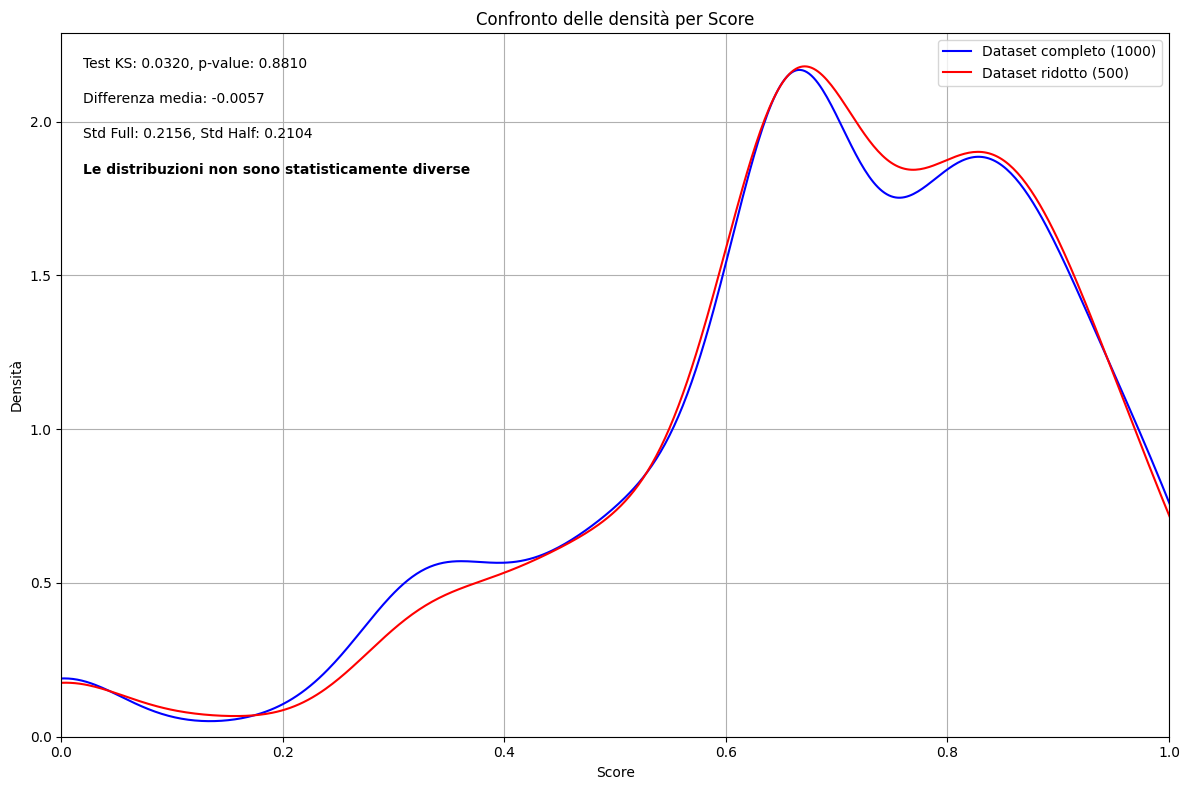

=== Statistiche per Score ===
Dataset completo (1000) - Media: 0.6848, Std: 0.2156
Dataset ridotto (500) - Media: 0.6905, Std: 0.2104
Test Kolmogorov-Smirnov: statistica=0.0320, p-value=0.8810
Interpretazione: Le distribuzioni non sono statisticamente diverse



In [19]:
plot_score("score", full_dataset_df, half_dataset_df)

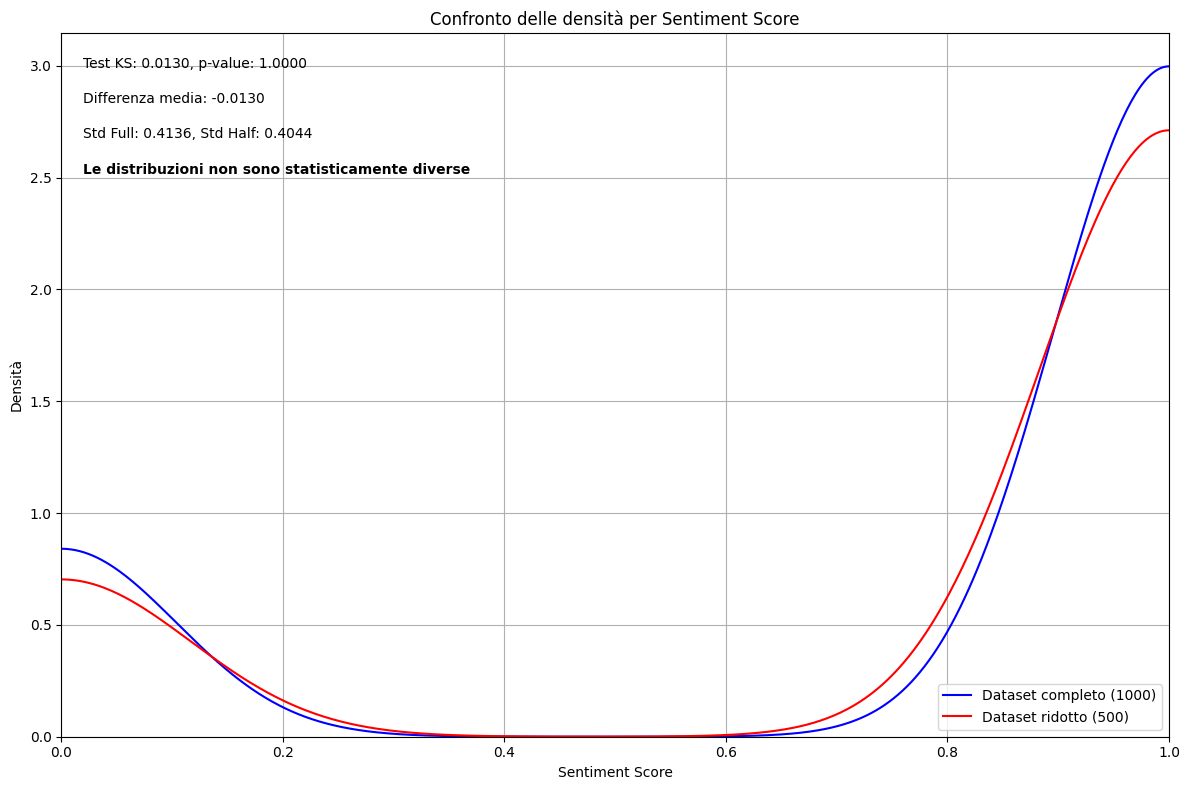

=== Statistiche per Sentiment Score ===
Dataset completo (1000) - Media: 0.7810, Std: 0.4136
Dataset ridotto (500) - Media: 0.7940, Std: 0.4044
Test Kolmogorov-Smirnov: statistica=0.0130, p-value=1.0000
Interpretazione: Le distribuzioni non sono statisticamente diverse



In [20]:
plot_score("sentiment_score", full_dataset_df, half_dataset_df)

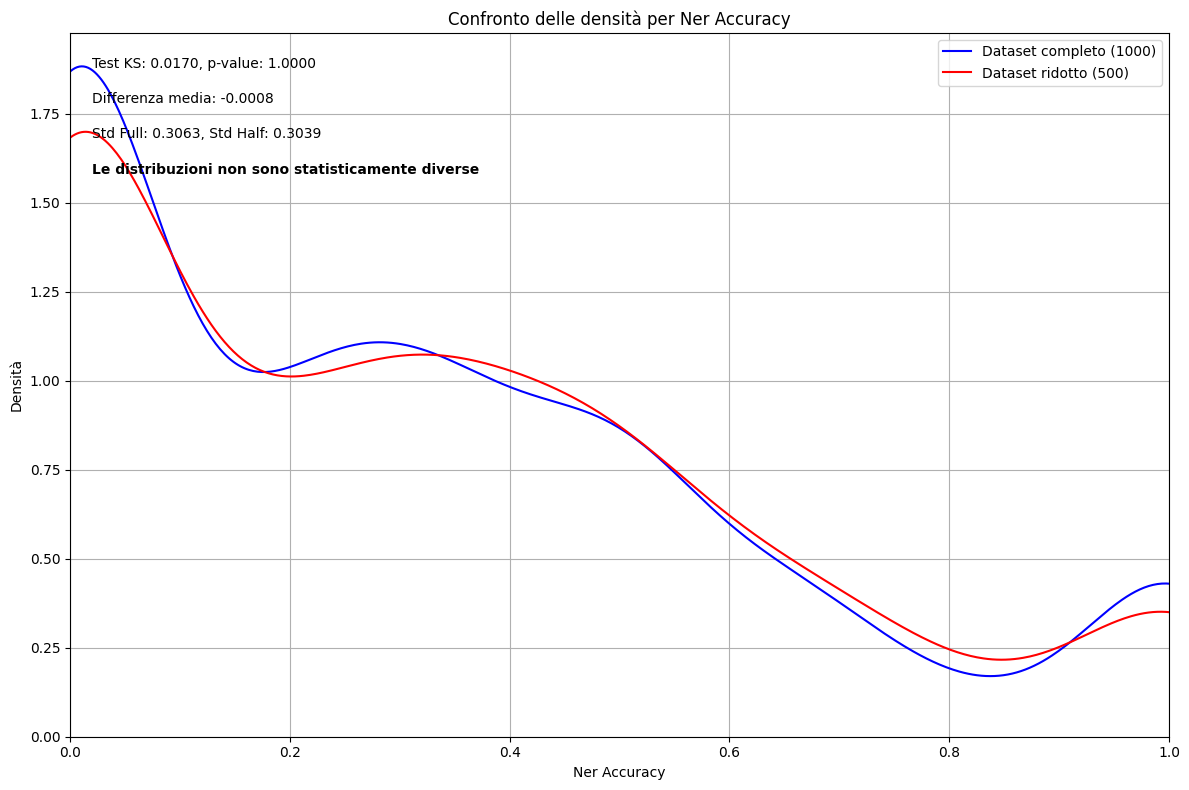

=== Statistiche per Ner Accuracy ===
Dataset completo (1000) - Media: 0.3048, Std: 0.3063
Dataset ridotto (500) - Media: 0.3056, Std: 0.3039
Test Kolmogorov-Smirnov: statistica=0.0170, p-value=1.0000
Interpretazione: Le distribuzioni non sono statisticamente diverse



In [21]:
plot_score("ner_accuracy", full_dataset_df, half_dataset_df)

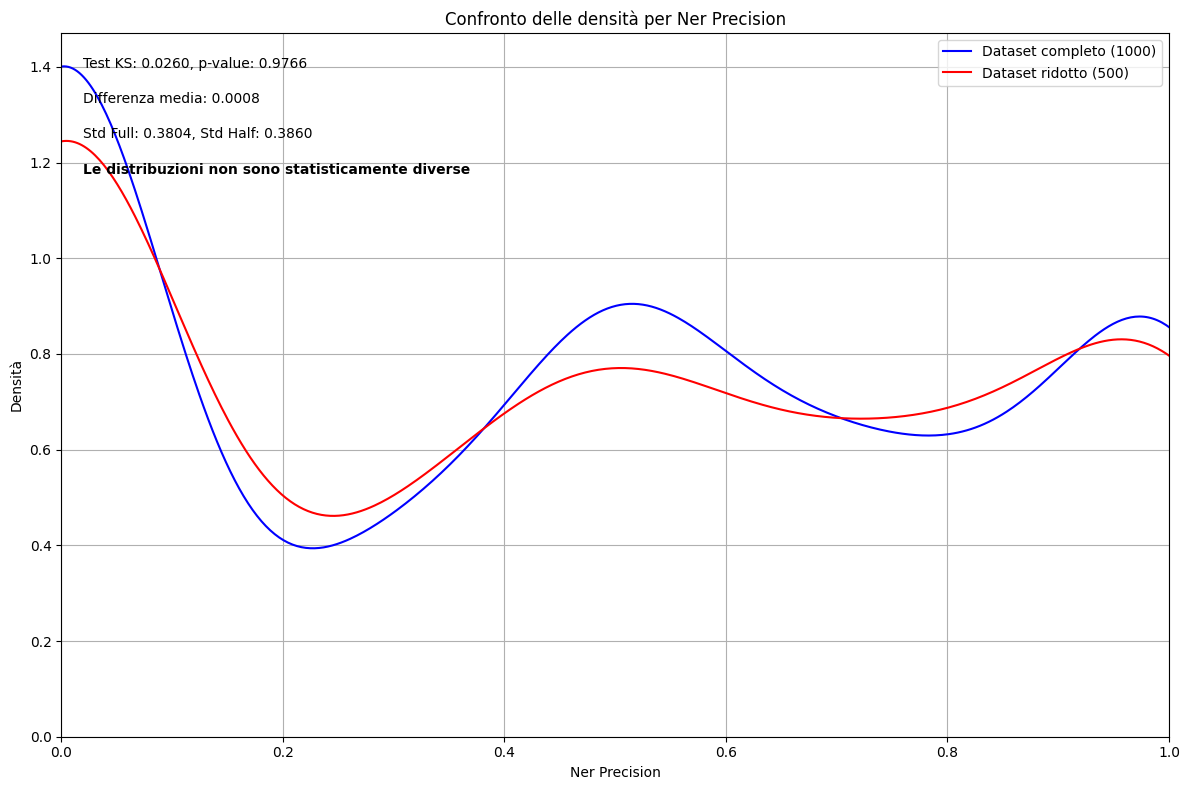

=== Statistiche per Ner Precision ===
Dataset completo (1000) - Media: 0.4530, Std: 0.3804
Dataset ridotto (500) - Media: 0.4522, Std: 0.3860
Test Kolmogorov-Smirnov: statistica=0.0260, p-value=0.9766
Interpretazione: Le distribuzioni non sono statisticamente diverse



In [22]:
plot_score("ner_precision", full_dataset_df, half_dataset_df)

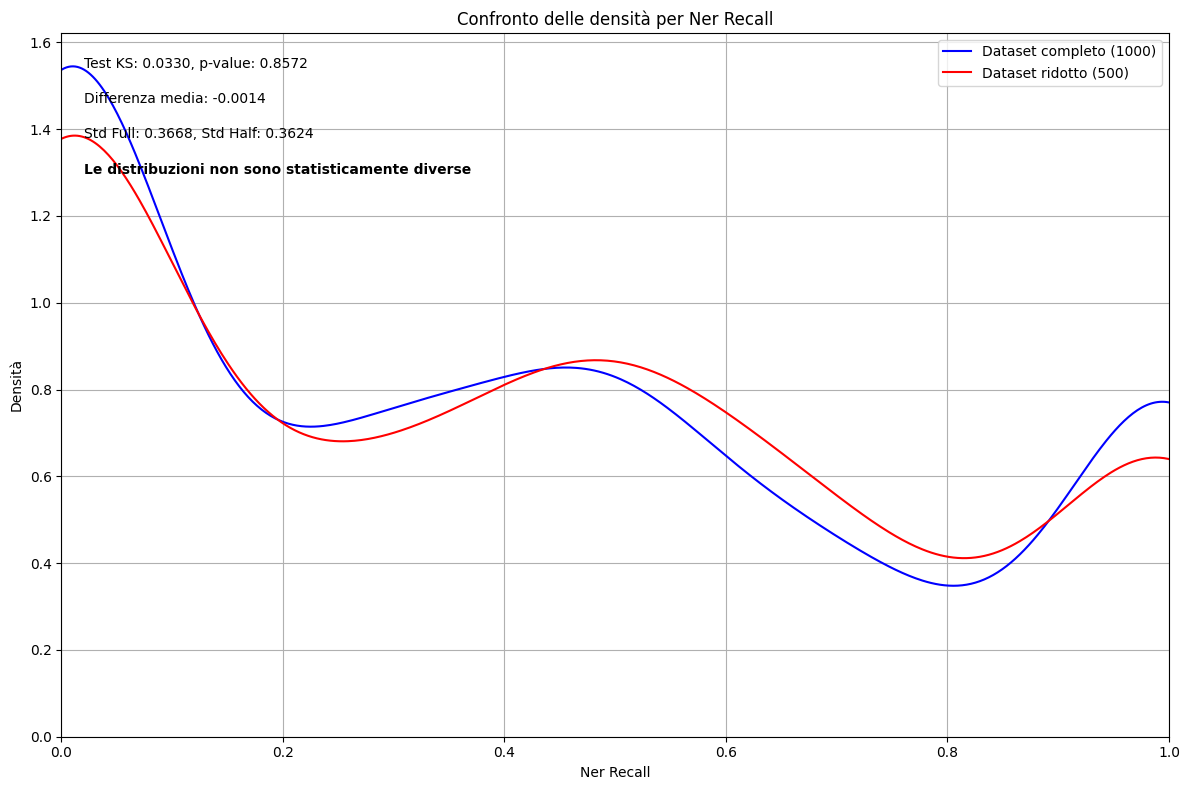

=== Statistiche per Ner Recall ===
Dataset completo (1000) - Media: 0.3901, Std: 0.3668
Dataset ridotto (500) - Media: 0.3916, Std: 0.3624
Test Kolmogorov-Smirnov: statistica=0.0330, p-value=0.8572
Interpretazione: Le distribuzioni non sono statisticamente diverse



In [23]:
plot_score("ner_recall", full_dataset_df, half_dataset_df)

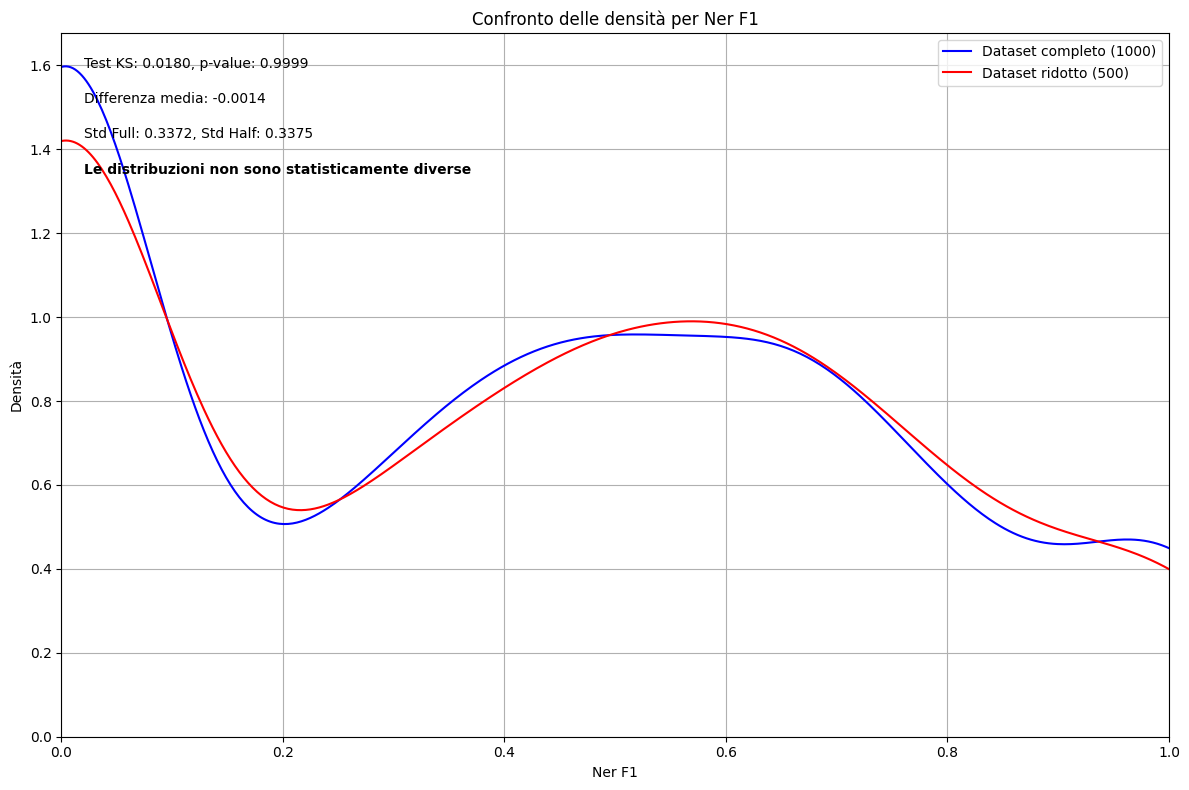

=== Statistiche per Ner F1 ===
Dataset completo (1000) - Media: 0.3898, Std: 0.3372
Dataset ridotto (500) - Media: 0.3913, Std: 0.3375
Test Kolmogorov-Smirnov: statistica=0.0180, p-value=0.9999
Interpretazione: Le distribuzioni non sono statisticamente diverse



In [24]:
plot_score("ner_f1", full_dataset_df, half_dataset_df)

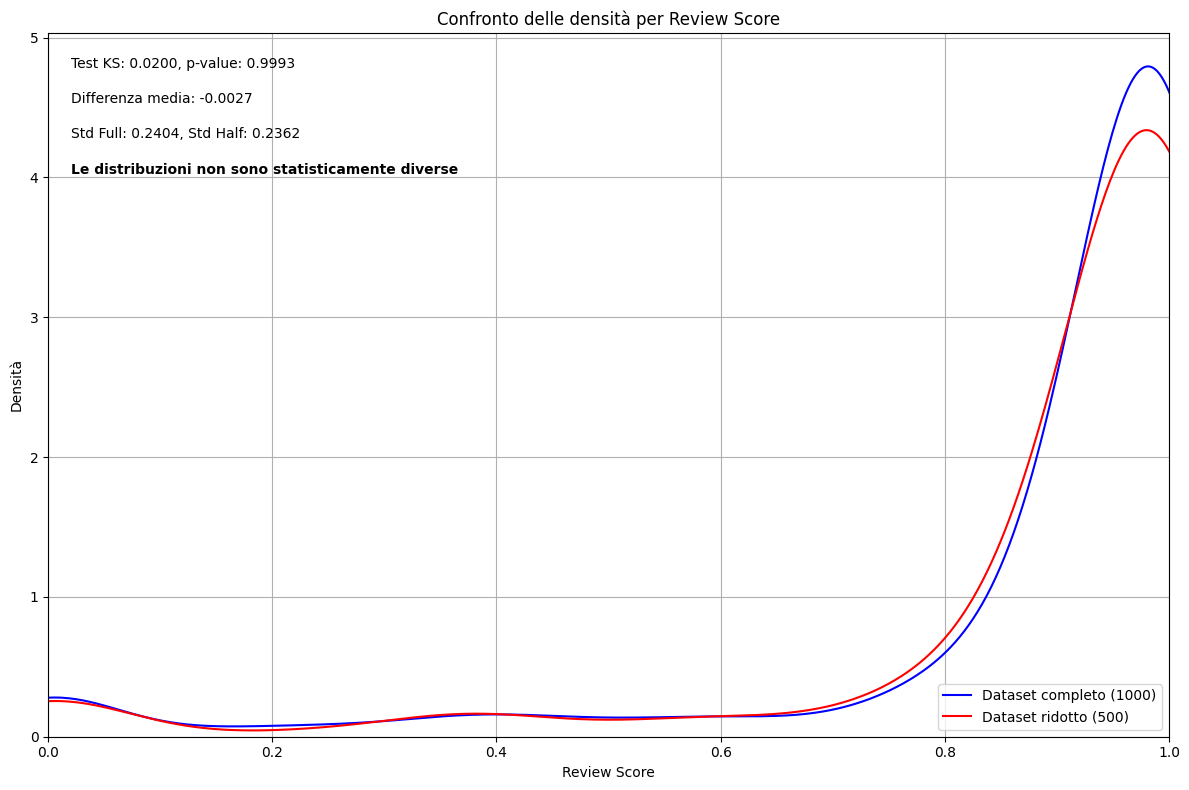

=== Statistiche per Review Score ===
Dataset completo (1000) - Media: 0.8836, Std: 0.2404
Dataset ridotto (500) - Media: 0.8864, Std: 0.2362
Test Kolmogorov-Smirnov: statistica=0.0200, p-value=0.9993
Interpretazione: Le distribuzioni non sono statisticamente diverse



In [25]:
plot_score("review_score", full_dataset_df, half_dataset_df)

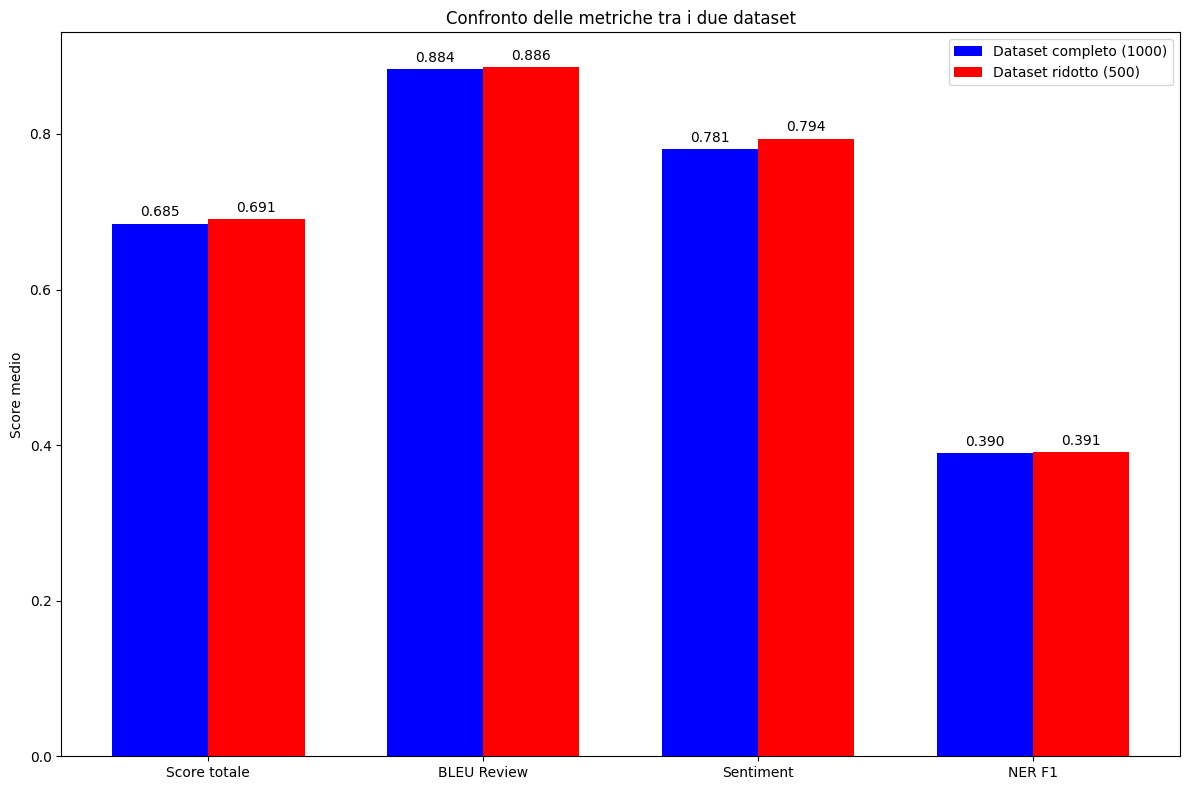

In [26]:
metrics = ["score", "review_score", "sentiment_score", "ner_f1"]
metrics_names = ["Score totale", "BLEU Review", "Sentiment", "NER F1"]

fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(metrics))
width = 0.35

full_means = [np.mean(full_dataset_df[m]) for m in metrics]
half_means = [np.mean(half_dataset_df[m]) for m in metrics]

rects1 = ax.bar(x - width/2, full_means, width, label='Dataset completo (1000)', color='blue')
rects2 = ax.bar(x + width/2, half_means, width, label='Dataset ridotto (500)', color='red')

ax.set_ylabel('Score medio')
ax.set_title('Confronto delle metriche tra i due dataset')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()

# Aggiungiamo i valori sopra le barre
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# Aggiungiamo una riga per la significatività statistica
significative = []
for m in metrics:
    _, p_value = stats.ks_2samp(full_dataset_df[m], half_dataset_df[m])
    significative.append(p_value < 0.05)

for i, sig in enumerate(significative):
    if sig:
        ax.text(i, 0.02, '*', ha='center', fontsize=20, color='black')

plt.tight_layout()
plt.savefig("gemma3_4b - summary_comparison_multicall.png", format='png', dpi=300)
plt.show()

In [27]:
full_dataset_df.to_csv(full_dataset_path.replace(".csv", "_evaluated_multicall.csv"), index=False)
half_dataset_df.to_csv(half_dataset_path.replace(".csv", "_evaluated_multicall.csv"), index=False)

In [28]:
summary_table = pd.DataFrame({
    'Metrica': metrics_names,
    'Dataset completo (1000)': [f"{np.mean(full_dataset_df[m]):.4f} ± {np.std(full_dataset_df[m]):.4f}" for m in metrics],
    'Dataset ridotto (500)': [f"{np.mean(half_dataset_df[m]):.4f} ± {np.std(half_dataset_df[m]):.4f}" for m in metrics],
    'Differenza %': [f"{(np.mean(full_dataset_df[m]) - np.mean(half_dataset_df[m])) / np.mean(full_dataset_df[m]) * 100:.2f}%" for m in metrics],
    'Statisticamente diversi': ['Sì' if stats.ks_2samp(full_dataset_df[m], half_dataset_df[m])[1] < 0.05 else 'No' for m in metrics]
})

print(summary_table)
summary_table.to_csv("gemma3_4b_comparison_summary_multicall.csv", index=False)

        Metrica Dataset completo (1000) Dataset ridotto (500) Differenza %  \
0  Score totale         0.6848 ± 0.2156       0.6905 ± 0.2104       -0.84%   
1   BLEU Review         0.8836 ± 0.2404       0.8864 ± 0.2362       -0.31%   
2     Sentiment         0.7810 ± 0.4136       0.7940 ± 0.4044       -1.66%   
3        NER F1         0.3898 ± 0.3372       0.3913 ± 0.3375       -0.37%   

  Statisticamente diversi  
0                      No  
1                      No  
2                      No  
3                      No  
